# Neuroevolution on Snake

Fifth notebook, and an honest one: unlike
[0004-neuroevolution-reach1d](0004-neuroevolution-reach1d.ipynb), this one does **not** end with
a clean win. `games.snake.Snake` (docs/design/0003 "datasets and games" plan) turned out to be a
genuinely harder learning problem for a small, fixed-topology network trained by mutation-only ES
than `reach1d` was — real, measured improvement, but modest and inconsistent across scenarios. Kept
here as-is, same principle as 0004's real bug: report what actually happened, not what would look
best.

**A second real bug/lesson, found by running this, not by reasoning about it in advance**: the
first reward function used symmetric distance shaping (+0.01 for moving closer to food, -0.01 for
moving farther). The evolved policy discovered it could oscillate between two cells forever for
~0 net reward — safer than continuing to risk death seeking food. Fixed by making the "farther"
penalty (-0.02) outweigh the "closer" reward, so standing still is strictly worse than seeking the
goal. See `games/snake.py` and `docs/CODING_GUIDELINES.md`.

In [1]:
import random

import matplotlib.pyplot as plt

from evolve import GaussianMutation, SimulationFitnessEvaluator, TournamentSelection, evolve, random_weight_vector
from games.rendering import render_grid_ascii
from games.snake import Snake, benchmark_environments

## Setup

The observation is the whole 10x10 board flattened (100 floats), a deliberately chosen tradeoff
over a small hand-engineered feature vector — more information-complete, but a much larger input
for a small network to learn from, and (spoiler) that tradeoff shows up in the results below.

**Methodological note**: earlier notebooks average over 10 seeds for statistical honesty. One
training run here takes ~3 minutes (a 100-input network evaluated over up to 150 steps x 5
scenarios x 150 generations x 80 individuals adds up) — 10 seeds would be ~30 minutes, impractical
for this notebook. This runs **one** seed. Take the single curve below as illustrative, not as
rigorously averaged as 0001-0004's comparisons.

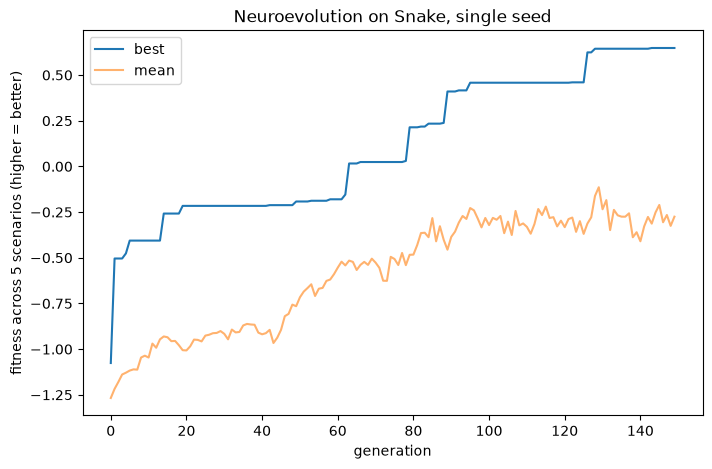

gen0  best=-1.076  mean=-1.267
final best=0.648  mean=-0.275


In [2]:
WIDTH, HEIGHT = 10, 10
LAYER_SIZES = (WIDTH * HEIGHT, 24, 3)
POPULATION_SIZE = 80
GENERATIONS = 150
MAX_STEPS = 150


def act(genome, observation):
    outputs = genome.forward(observation)
    best_index = max(range(3), key=lambda i: outputs[i])
    return best_index - 1  # 0,1,2 -> -1,0,1 (left, straight, right)


rng = random.Random(0)
population = [random_weight_vector(LAYER_SIZES, rng, scale=0.5) for _ in range(POPULATION_SIZE)]
fitness = SimulationFitnessEvaluator(envs=benchmark_environments(), act=act, max_steps=MAX_STEPS)
summaries = []
evolve(
    population,
    fitness=fitness,
    selection=TournamentSelection(k=4),
    variation=GaussianMutation(sigma=0.2),
    generations=GENERATIONS,
    on_generation=[summaries.append],
    rng=rng,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(len(summaries)), [s.best_fitness for s in summaries], label="best")
ax.plot(range(len(summaries)), [s.mean_fitness for s in summaries], label="mean", alpha=0.6)
ax.set_xlabel("generation")
ax.set_ylabel("fitness across 5 scenarios (higher = better)")
ax.set_title("Neuroevolution on Snake, single seed")
ax.legend()
plt.show()

print(f"gen0  best={summaries[0].best_fitness:.3f}  mean={summaries[0].mean_fitness:.3f}")
print(f"final best={summaries[-1].best_fitness:.3f}  mean={summaries[-1].mean_fitness:.3f}")

## What the champion actually does

Best fitness clearly improved (real learning happened) but mean fitness stayed negative — across
the 5 benchmark scenarios, the champion doesn't perform consistently well. Replaying it on each
scenario shows exactly that: it eats food and survives meaningfully longer than a random policy on
some scenarios, and dies almost immediately on others.

In [3]:
champion = summaries[-1].champion
results = []
for i, env in enumerate(benchmark_environments()):
    observation = env.reset()
    steps_survived = 0
    for step in range(MAX_STEPS):
        observation, _reward, done = env.step(act(champion, observation))
        steps_survived = step + 1
        if done:
            break
    results.append((i, env.score, steps_survived))
    print(f"scenario {i}: score={env.score}  survived={steps_survived} steps")

best_scenario = max(results, key=lambda r: r[1])[0]
print(f"\nReplaying the best-performing scenario ({best_scenario}) step by step:")

scenario 0: score=2  survived=24 steps
scenario 1: score=1  survived=18 steps
scenario 2: score=0  survived=5 steps
scenario 3: score=3  survived=36 steps
scenario 4: score=2  survived=20 steps

Replaying the best-performing scenario (3) step by step:


In [4]:
symbols = {"head": "@", "body": "o", "food": "*"}
env = benchmark_environments()[best_scenario]
observation = env.reset()
for step in range(MAX_STEPS):
    observation, _reward, done = env.step(act(champion, observation))
    if step % 8 == 0 or done:
        state = env.render_state()
        print(f"--- step {step}, score={state['score']}, alive={state['alive']} ---")
        print(render_grid_ascii(state["width"], state["height"], state["cells"], symbols))
    if done:
        break

--- step 0, score=0, alive=True ---
...*......
..........
..........
..........
.....@....
....oo....
..........
..........
..........
..........
--- step 8, score=1, alive=True ---
..ooo.....
..@.......
..........
..........
..........
..........
..........
..........
..........
.......*..
--- step 16, score=1, alive=True ---
..........
..........
..........
..........
..........
..........
..o.......
..o.......
..o.......
..@....*..
--- step 24, score=2, alive=True ---
..........
..........
..........
.......*..
..........
..........
..........
........@.
.......oo.
......oo..
--- step 32, score=3, alive=True ---
..........
..........
..........
......ooo.
......o@o.
..........
.*........
..........
..........
..........
--- step 35, score=3, alive=False ---
..........
..........
..........
......oo..
......oo..
......@o..
.*........
..........
..........
..........


## Why this is harder than reach1d

A plausible explanation, not a proven one: `reach1d`'s observation was 2 numbers; Snake's is 100.
A `(100, 24, 3)` network has ~2,500 weights for mutation-only ES to search, versus `reach1d`'s
`(2, 8, 1)` network at ~33. Evolution strategies scale to large parameter counts eventually, but
"eventually" here plausibly means more generations and/or a larger population than this notebook
budgeted for — and this is exactly the tradeoff flagged before Snake's observation shape was chosen
(flattened grid vs. a small hand-engineered feature vector). This notebook is real evidence for
that tradeoff having a real cost, not just a theoretical one.

Candidates for closing the gap, in rough order of effort: more generations/population (cheapest,
least interesting); a hand-engineered feature observation instead of the flattened grid (revisits
the original decision, directly testable by rerunning this same setup with a different
`SimulationFitnessEvaluator`'s `act` and a smaller `layer_sizes`); or NEAT-style topology evolution
(docs/design/0003's landscape survey) instead of fixed-topology weight mutation — a genuinely
different algorithmic direction, not just more compute.

## Takeaways

- `evolve()`/`TournamentSelection`/`GaussianMutation` needed zero changes for a 3-way discrete
  action space — only `WeightVector.forward()` (all outputs, for argmax) alongside the existing
  `act()` (first output only, for reach1d's bounded scalar).
  `games.rendering.render_grid_ascii()` is the first utility actually reused across games, the
  point of consolidating into one `libs/games` package in the first place.
- Real learning happened (best fitness: -1.08 to +0.65) but isn't consistently good across
  scenarios — reported as-is rather than tuned until it looked better, same principle as every
  other honest result in this repo's notebooks.
- Two real lessons found by running, not by design review: `reach1d`'s observability gap (0004),
  and this notebook's reward-hacking oscillation. Both are now in
  `docs/CODING_GUIDELINES.md`'s "Simulations / RL environments" section.
- Per docs/design/0003's roadmap, next is the small from-scratch transformer/LM (phase 6) —
  independent of whether Snake gets revisited with a bigger network or engineered features first.